In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ── Consistent style across all plots ─────────────────────────────────────
PALETTE   = ["#6C63FF", "#FF6584", "#43B89C", "#F7C59F", "#3D5A80",
             "#E07A5F", "#F2CC8F", "#81B29A"]
ACCENT    = "#6C63FF"
BG        = "#F8F9FD"
TEXT_DARK = "#1E1E2E"

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": "white",
    "axes.edgecolor": "#E0E0E0", "axes.labelcolor": TEXT_DARK,
    "xtick.color": TEXT_DARK, "ytick.color": TEXT_DARK,
    "grid.color": "#EFEFEF", "grid.linewidth": 0.8, "font.size": 11,
})

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
# UPDATE THIS PATH to wherever you saved student_cleaned.csv
DATA_PATH = r"C:/Users/user/JobGenie/Student/Dataset/student_cleaned.csv"

df = pd.read_csv(DATA_PATH)

print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head(3)


✅ Loaded: 5,000 rows × 16 columns

Columns: ['college_tier', 'cgpa', 'internships', 'github_projects', 'backlogs', 'hackathons', 'certifications', 'advanced_skills', 'intermediate_skills', 'basic_skills', 'aptitude_score', 'job_role', 'salary_lpa', 'college_tier_encoded', 'job_role_encoded', 'salary_log']

Missing values: 0


,college_tier,cgpa,internships,github_projects,backlogs,hackathons,certifications,advanced_skills,intermediate_skills,basic_skills,aptitude_score,job_role,salary_lpa,college_tier_encoded,job_role_encoded,salary_log
0,Tier 2,7.60,2,1,1,1,3,0,1,0,52.5,Software Engineer,10.23,2,6,2.418589
1,Tier 2,5.89,1,2,0,1,2,2,0,0,46.5,Web Developer,6.03,2,7,1.950187
2,Tier 1,5.62,0,4,1,0,1,1,2,1,45.2,Junior Developer,5.93,3,4,1.935860


In [5]:
feature_cols = [
    'cgpa', 'internships', 'github_projects', 'backlogs',
    'hackathons', 'certifications', 'advanced_skills',
    'intermediate_skills', 'basic_skills', 'aptitude_score', 'salary_lpa'
]

desc = df[feature_cols].describe().round(2)
print("📊 Descriptive Statistics:")
desc


📊 Descriptive Statistics:


,cgpa,internships,github_projects,backlogs,hackathons,certifications,advanced_skills,intermediate_skills,basic_skills,aptitude_score,salary_lpa
count,5000.00,5000.0,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,7.02,1.0,1.98,0.76,1.50,2.01,0.81,1.15,1.03,52.26,10.73
std,1.18,1.0,1.41,0.90,1.22,1.39,0.82,0.97,0.90,10.38,5.30
min,4.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,19.90,2.04
25%,6.22,0.0,1.00,0.00,1.00,1.00,0.00,0.00,0.00,45.10,6.44
50%,7.01,1.0,2.00,1.00,1.00,2.00,1.00,1.00,1.00,52.30,9.99
75%,7.83,2.0,3.00,1.00,2.00,3.00,1.00,2.00,2.00,59.20,14.69
max,10.00,7.0,10.00,7.00,8.00,8.00,4.00,5.00,5.00,83.50,31.52


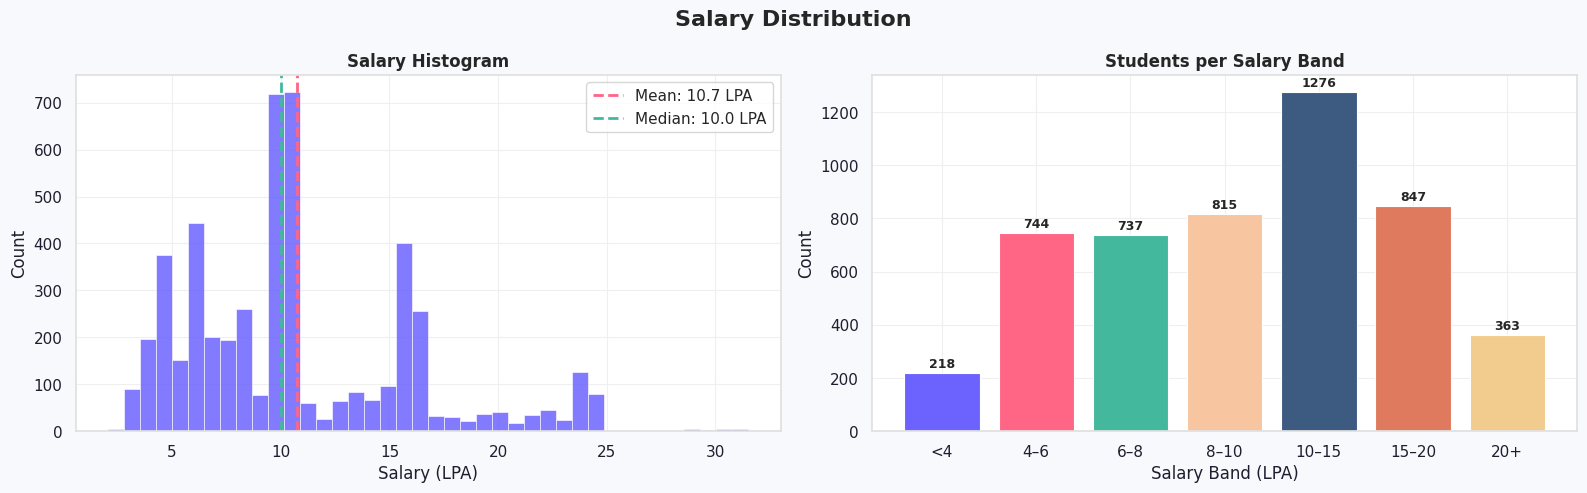


📌 Salary skewness: 0.9436
   → Moderate right skew — Random Forest handles this well. No log transform needed.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG)
fig.suptitle("Salary Distribution", fontsize=16, fontweight="bold")

# Histogram
ax = axes[0]
ax.hist(df['salary_lpa'], bins=40, color=ACCENT, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(df['salary_lpa'].mean(),   color="#FF6584", lw=2, ls='--',
           label=f"Mean: {df['salary_lpa'].mean():.1f} LPA")
ax.axvline(df['salary_lpa'].median(), color="#43B89C", lw=2, ls='--',
           label=f"Median: {df['salary_lpa'].median():.1f} LPA")
ax.set_title("Salary Histogram", fontweight="bold")
ax.set_xlabel("Salary (LPA)"); ax.set_ylabel("Count")
ax.legend()

# Salary bands bar chart
ax = axes[1]
bins   = [0, 4, 6, 8, 10, 15, 20, 50]
labels = ['<4', '4–6', '6–8', '8–10', '10–15', '15–20', '20+']
band_counts = pd.cut(df['salary_lpa'], bins=bins, labels=labels).value_counts().sort_index()
bars = ax.bar(band_counts.index, band_counts.values, color=PALETTE[:len(band_counts)],
              edgecolor='white', linewidth=0.8)
for bar, v in zip(bars, band_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+10, str(v),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Students per Salary Band", fontweight="bold")
ax.set_xlabel("Salary Band (LPA)"); ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

skew = df['salary_lpa'].skew()
print(f"\n📌 Salary skewness: {skew:.4f}")
print(f"   {'→ Moderate right skew — Random Forest handles this well. No log transform needed.' if skew < 1.5 else '→ High skew — consider log transform for linear models.'}")


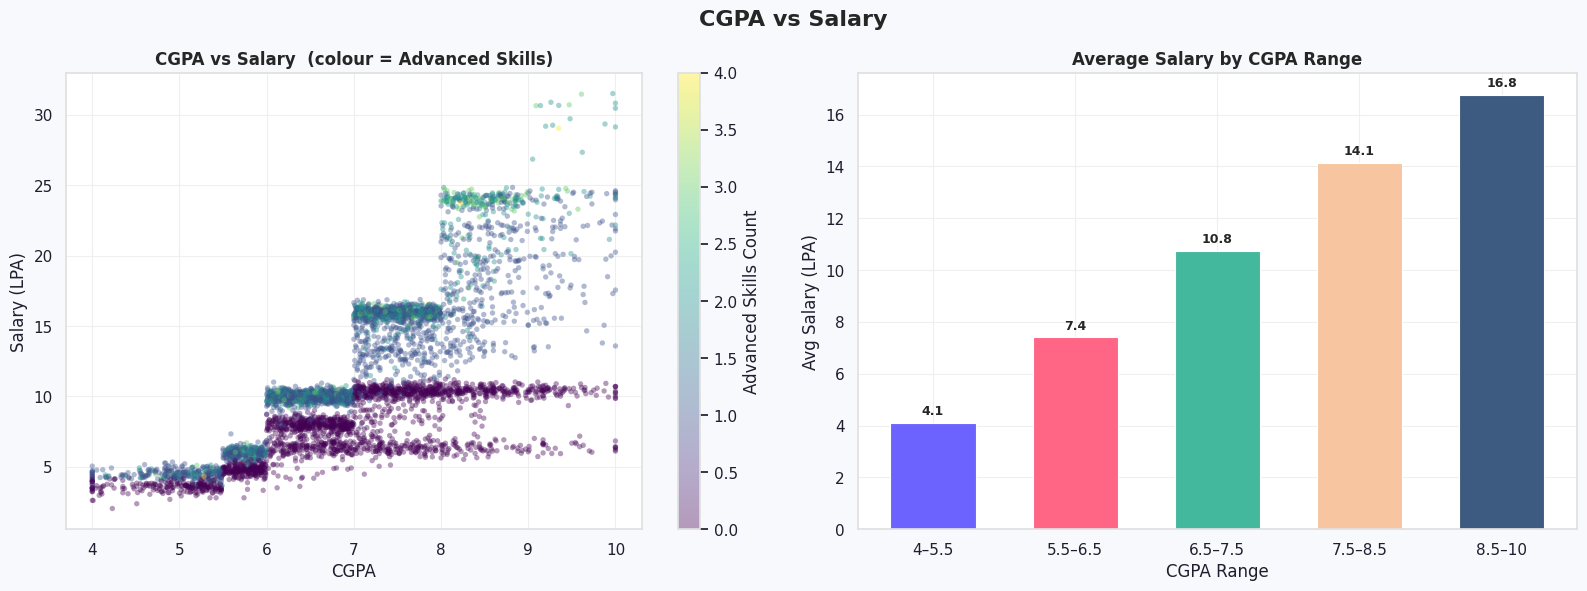


📌 CGPA–Salary correlation: 0.721
   → Strong positive correlation. CGPA is the most important feature.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("CGPA vs Salary", fontsize=16, fontweight="bold")

# Scatter coloured by advanced skills count
ax = axes[0]
sc = ax.scatter(df['cgpa'], df['salary_lpa'], c=df['advanced_skills'],
                cmap='viridis', alpha=0.4, s=15, linewidths=0)
plt.colorbar(sc, ax=ax, label='Advanced Skills Count')
ax.set_title("CGPA vs Salary  (colour = Advanced Skills)", fontweight="bold")
ax.set_xlabel("CGPA"); ax.set_ylabel("Salary (LPA)")

# Bar: avg salary per CGPA band
ax = axes[1]
df['cgpa_bin'] = pd.cut(df['cgpa'], bins=[4, 5.5, 6.5, 7.5, 8.5, 10],
                         labels=['4–5.5', '5.5–6.5', '6.5–7.5', '7.5–8.5', '8.5–10'])
cgpa_sal = df.groupby('cgpa_bin', observed=True)['salary_lpa'].mean()
bars = ax.bar(cgpa_sal.index, cgpa_sal.values, color=PALETTE[:5],
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, v in zip(bars, cgpa_sal.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.1f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Average Salary by CGPA Range", fontweight="bold")
ax.set_xlabel("CGPA Range"); ax.set_ylabel("Avg Salary (LPA)")

plt.tight_layout()
plt.show()

print("\n📌 CGPA–Salary correlation:", round(df['cgpa'].corr(df['salary_lpa']), 3))
print("   → Strong positive correlation. CGPA is the most important feature.")


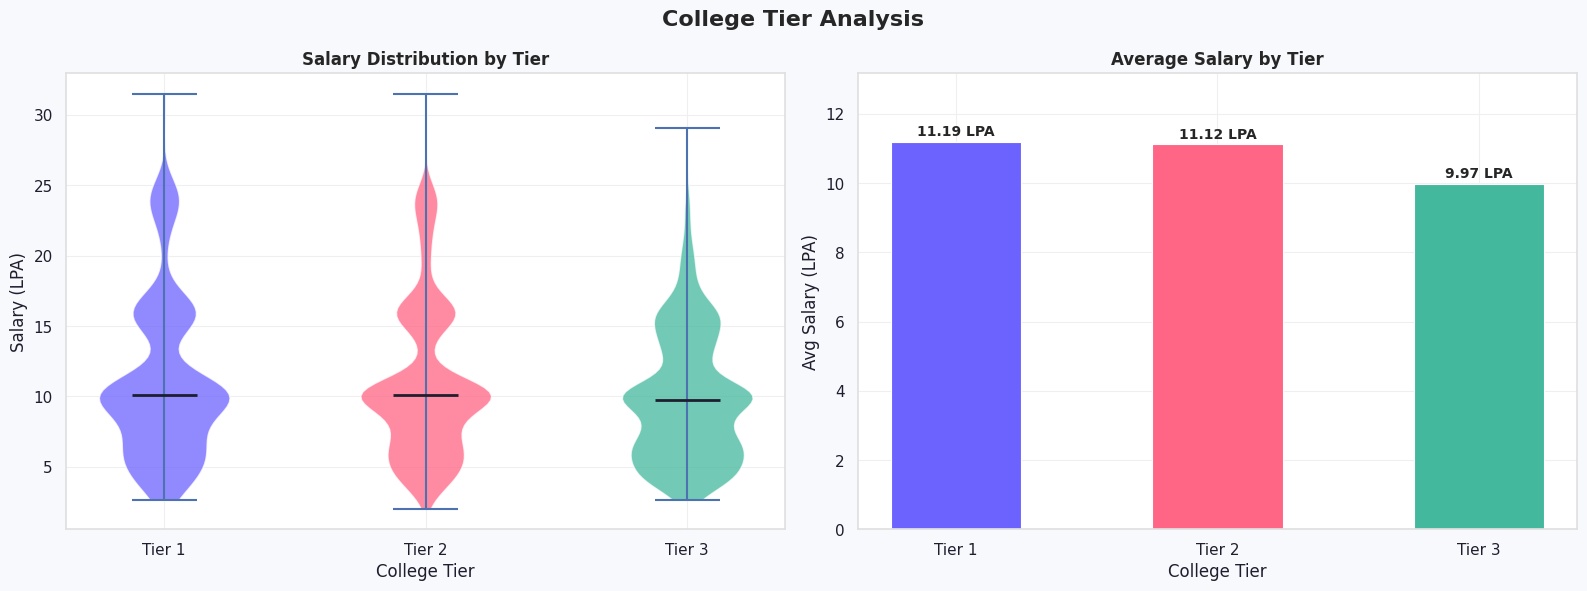


📌 Tier–Salary correlation: 0.093
   → Weak correlation (0.09). Tier alone doesn't determine salary — CGPA and skills matter more.

📊 Mean salary by tier:
   Tier 1: 11.19 LPA
   Tier 2: 11.12 LPA
   Tier 3: 9.97 LPA


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("College Tier Analysis", fontsize=16, fontweight="bold")

tier_order = ["Tier 1", "Tier 2", "Tier 3"]

# Violin plot
ax = axes[0]
parts = ax.violinplot(
    [df[df.college_tier == t]['salary_lpa'].values for t in tier_order],
    positions=[1, 2, 3], showmedians=True
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i]); pc.set_alpha(0.75)
parts['cmedians'].set_color('#1E1E2E'); parts['cmedians'].set_linewidth(2)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(tier_order)
ax.set_title("Salary Distribution by Tier", fontweight="bold")
ax.set_xlabel("College Tier"); ax.set_ylabel("Salary (LPA)")

# Avg salary bar
ax = axes[1]
tier_sal = df.groupby('college_tier')['salary_lpa'].mean()[tier_order]
bars = ax.bar(tier_sal.index, tier_sal.values, color=PALETTE[:3],
              edgecolor='white', linewidth=0.8, width=0.5)
for bar, v in zip(bars, tier_sal.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f"{v:.2f} LPA",
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, tier_sal.max() + 2)
ax.set_title("Average Salary by Tier", fontweight="bold")
ax.set_xlabel("College Tier"); ax.set_ylabel("Avg Salary (LPA)")

plt.tight_layout()
plt.show()

print("\n📌 Tier–Salary correlation:", round(df['college_tier_encoded'].corr(df['salary_lpa']), 3))
print("   → Weak correlation (0.09). Tier alone doesn't determine salary — CGPA and skills matter more.")
print("\n📊 Mean salary by tier:")
for t in tier_order:
    mean_s = df[df.college_tier == t]['salary_lpa'].mean()
    print(f"   {t}: {mean_s:.2f} LPA")


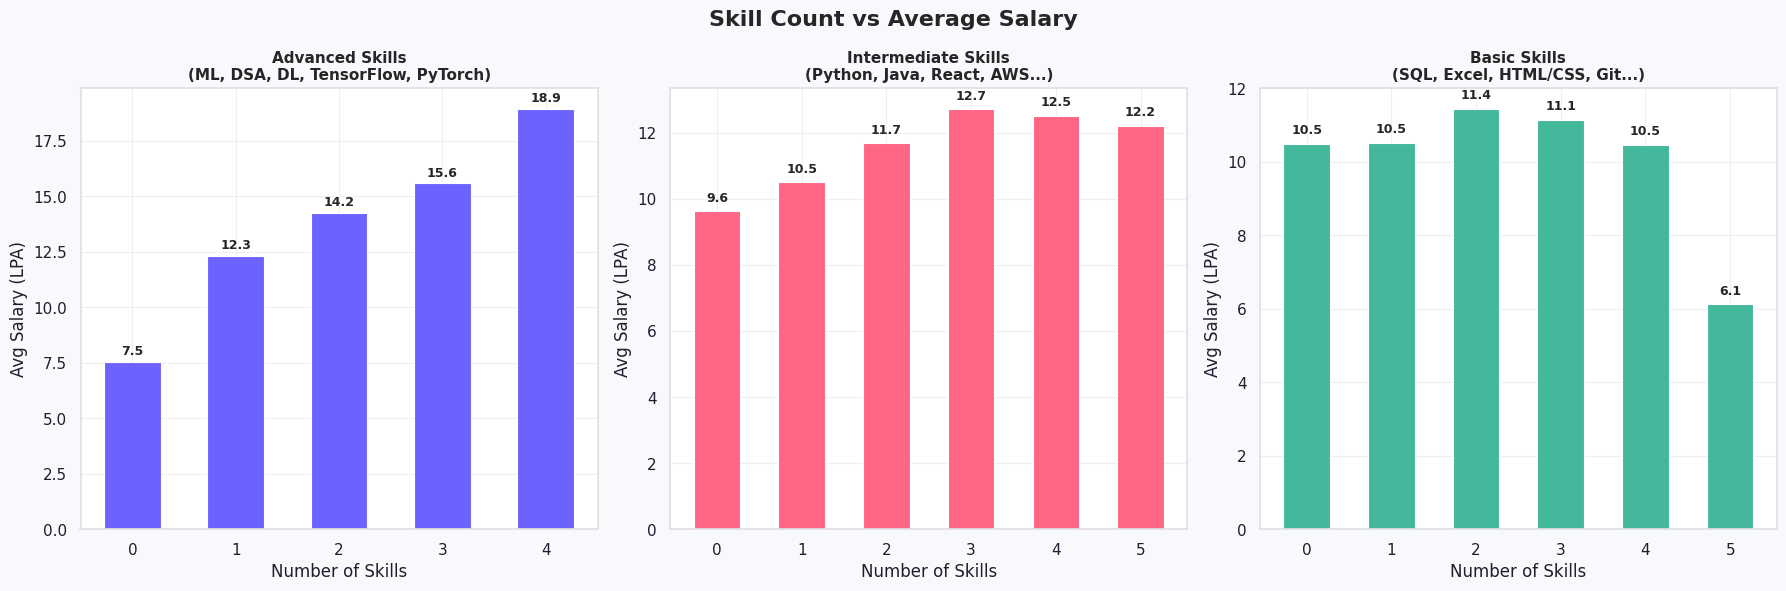


📌 Insight:
   Students with 0 advanced skills → Avg: 7.5 LPA
   Students with 2 advanced skills → Avg: 14.2 LPA
   → Advanced skill boost: +6.7 LPA for 2 advanced skills
   → Each advanced skill adds ~3–5 LPA on average.
   → Basic skills have near-zero marginal impact — expected.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Skill Count vs Average Salary", fontsize=16, fontweight="bold")

skill_info = [
    ('advanced_skills',     'Advanced Skills\n(ML, DSA, DL, TensorFlow, PyTorch)', PALETTE[0]),
    ('intermediate_skills', 'Intermediate Skills\n(Python, Java, React, AWS...)',   PALETTE[1]),
    ('basic_skills',        'Basic Skills\n(SQL, Excel, HTML/CSS, Git...)',          PALETTE[2]),
]

for ax, (col, title, color) in zip(axes, skill_info):
    grp = df.groupby(col)['salary_lpa'].mean()
    bars = ax.bar(grp.index.astype(str), grp.values, color=color,
                  edgecolor='white', linewidth=0.8, width=0.55)
    for bar, v in zip(bars, grp.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.1f}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Number of Skills"); ax.set_ylabel("Avg Salary (LPA)")

plt.tight_layout()
plt.show()

print("\n📌 Insight:")
adv0 = df[df.advanced_skills == 0]['salary_lpa'].mean()
adv2 = df[df.advanced_skills == 2]['salary_lpa'].mean() if 2 in df.advanced_skills.values else None
print(f"   Students with 0 advanced skills → Avg: {adv0:.1f} LPA")
if adv2:
    print(f"   Students with 2 advanced skills → Avg: {adv2:.1f} LPA")
    print(f"   → Advanced skill boost: +{adv2 - adv0:.1f} LPA for 2 advanced skills")
print("   → Each advanced skill adds ~3–5 LPA on average.")
print("   → Basic skills have near-zero marginal impact — expected.")


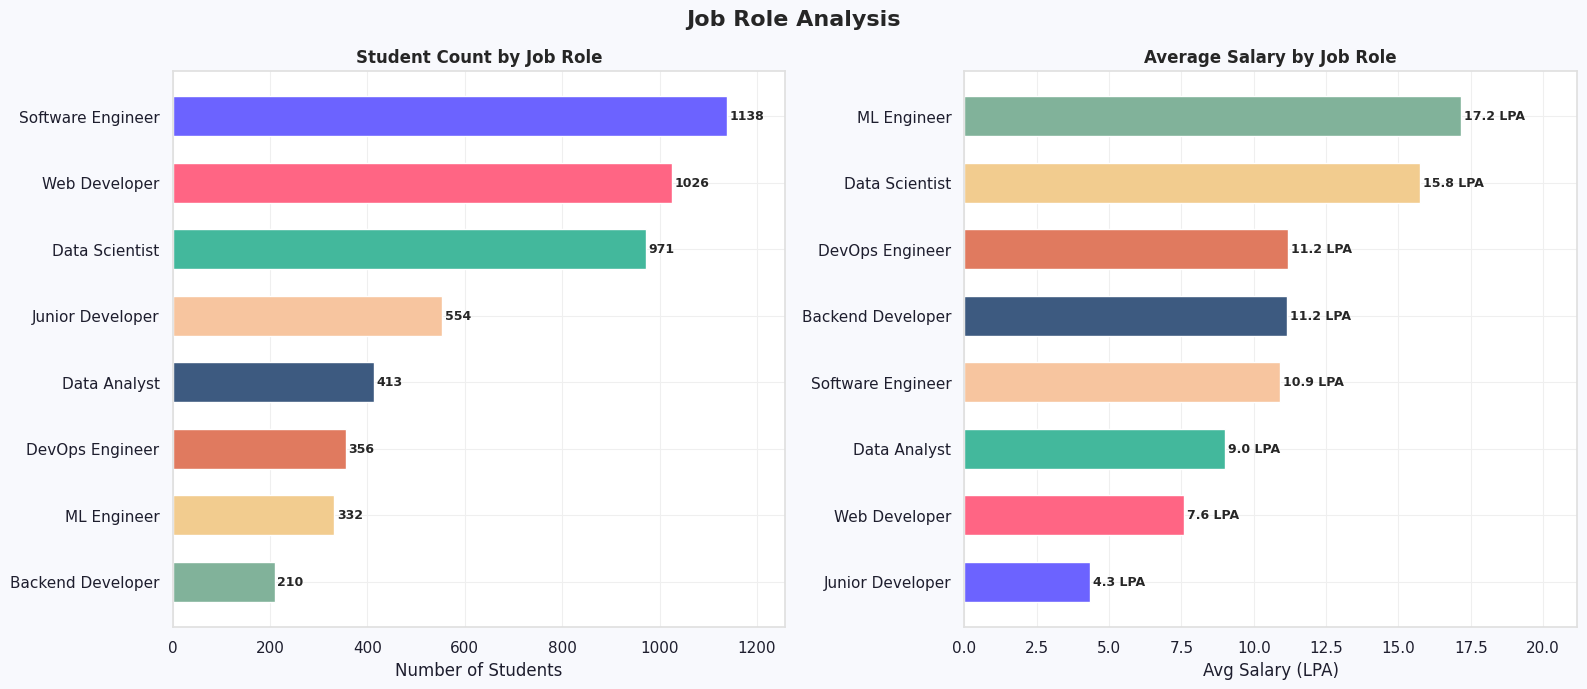


📌 Class Imbalance Report:
   Most common  : Software Engineer → 1138 students
   Least common : Backend Developer → 210 students
   Imbalance ratio: 5.4x

   ⚠️  High imbalance detected! Use class_weight=balanced in classifier.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)
fig.suptitle("Job Role Analysis", fontsize=16, fontweight="bold")

role_counts = df['job_role'].value_counts()

# ── LEFT: Student count per role (replaced pie chart) ─────────────────
ax = axes[0]
colors_count = [PALETTE[i % len(PALETTE)] for i in range(len(role_counts))]
bars = ax.barh(role_counts.index, role_counts.values,
               color=colors_count, edgecolor='white', height=0.6)
for bar, v in zip(bars, role_counts.values):
    ax.text(v + 5, bar.get_y() + bar.get_height()/2, str(v),
            va='center', fontsize=9, fontweight='bold')
ax.set_title("Student Count by Job Role", fontweight="bold")
ax.set_xlabel("Number of Students")
ax.set_xlim(0, role_counts.max() + 120)
ax.invert_yaxis()  # most common role on top

# ── RIGHT: Avg salary per role (unchanged) ────────────────────────────
ax = axes[1]
role_sal = df.groupby('job_role')['salary_lpa'].mean().sort_values()
colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(role_sal))]
bars = ax.barh(role_sal.index, role_sal.values,
               color=colors_bar, edgecolor='white', height=0.6)
for bar, v in zip(bars, role_sal.values):
    ax.text(v + 0.1, bar.get_y() + bar.get_height()/2, f"{v:.1f} LPA",
            va='center', fontsize=9, fontweight='bold')
ax.set_title("Average Salary by Job Role", fontweight="bold")
ax.set_xlabel("Avg Salary (LPA)")
ax.set_xlim(0, role_sal.max() + 4)

plt.tight_layout()
plt.show()

print("\n📌 Class Imbalance Report:")
print(f"   Most common  : {role_counts.idxmax()} → {role_counts.max()} students")
print(f"   Least common : {role_counts.idxmin()} → {role_counts.min()} students")
ratio = role_counts.max() / role_counts.min()
print(f"   Imbalance ratio: {ratio:.1f}x")
print(f"\n   ⚠️  {'High imbalance detected! Use class_weight=balanced in classifier.' if ratio > 4 else 'Moderate imbalance. Use class_weight=balanced as a precaution.'}")

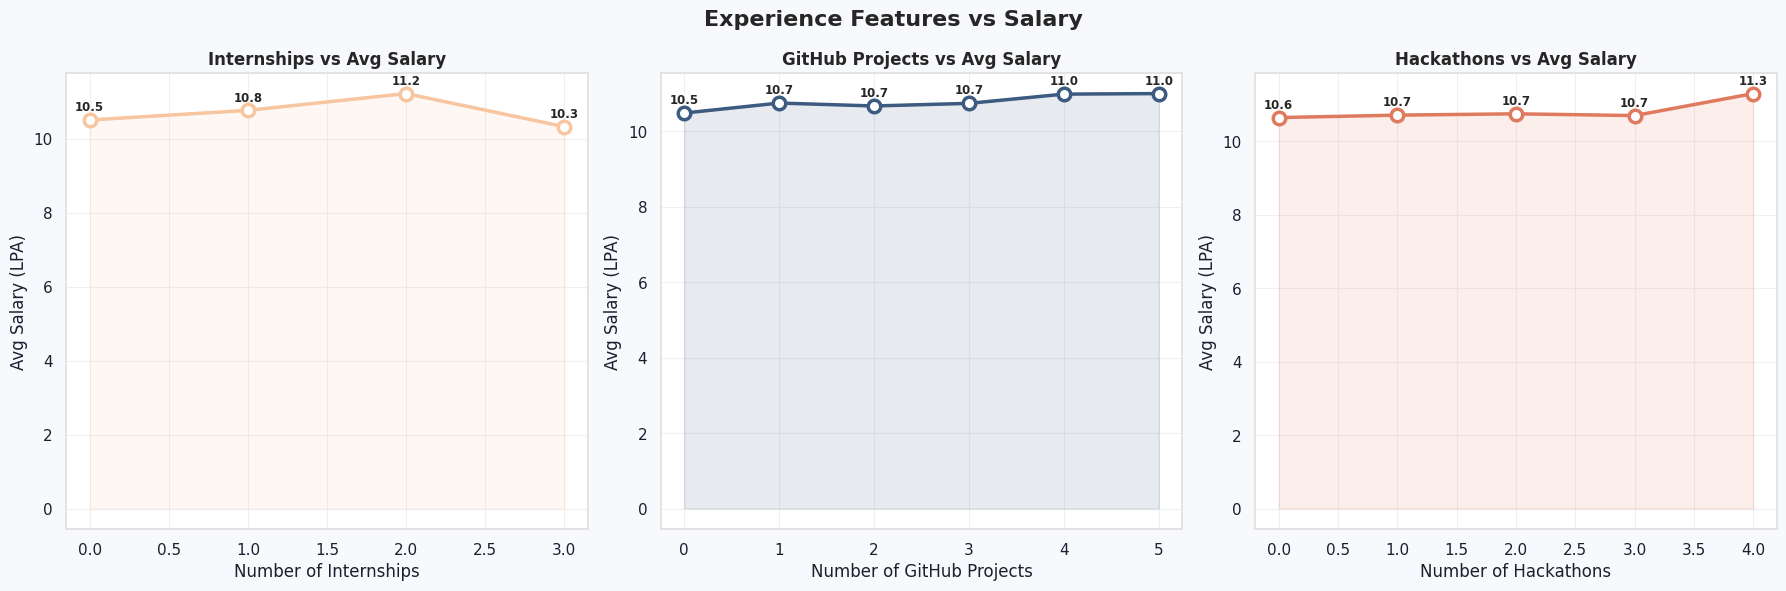


📌 Correlations with salary_lpa:
   Internships         :  0.025
   GitHub Projects     :  0.027
   Hackathons          :  0.019
   → These are weak correlations. Skills & CGPA dominate — experience is a secondary signal.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Experience Features vs Salary", fontsize=16, fontweight="bold")

exp_features = [
    ('internships',    'Internships',     PALETTE[3]),
    ('github_projects','GitHub Projects', PALETTE[4]),
    ('hackathons',     'Hackathons',      PALETTE[5]),
    ('certifications',  'Certifications',   PALETTE[6]),  
]

for ax, (col, title, color) in zip(axes, exp_features):
    cap = df[col].quantile(0.95)
    grp = df[df[col] <= cap].groupby(col)['salary_lpa'].mean()
    ax.plot(grp.index, grp.values, color=color, marker='o', markersize=9,
            linewidth=2.5, markerfacecolor='white', markeredgewidth=2.5)
    ax.fill_between(grp.index, grp.values, alpha=0.12, color=color)
    for x, y in zip(grp.index, grp.values):
        ax.text(x, y + 0.25, f"{y:.1f}", ha='center', fontsize=8.5, fontweight='bold')
    ax.set_title(f"{title} vs Avg Salary", fontweight="bold")
    ax.set_xlabel(f"Number of {title}"); ax.set_ylabel("Avg Salary (LPA)")

plt.tight_layout()
plt.show()

print("\n📌 Correlations with salary_lpa:")
for col, title, _ in exp_features:
    corr = round(df[col].corr(df['salary_lpa']), 3)
    print(f"   {title:<20}: {corr:>6}")
print("   → These are weak correlations. Skills & CGPA dominate — experience is a secondary signal.")


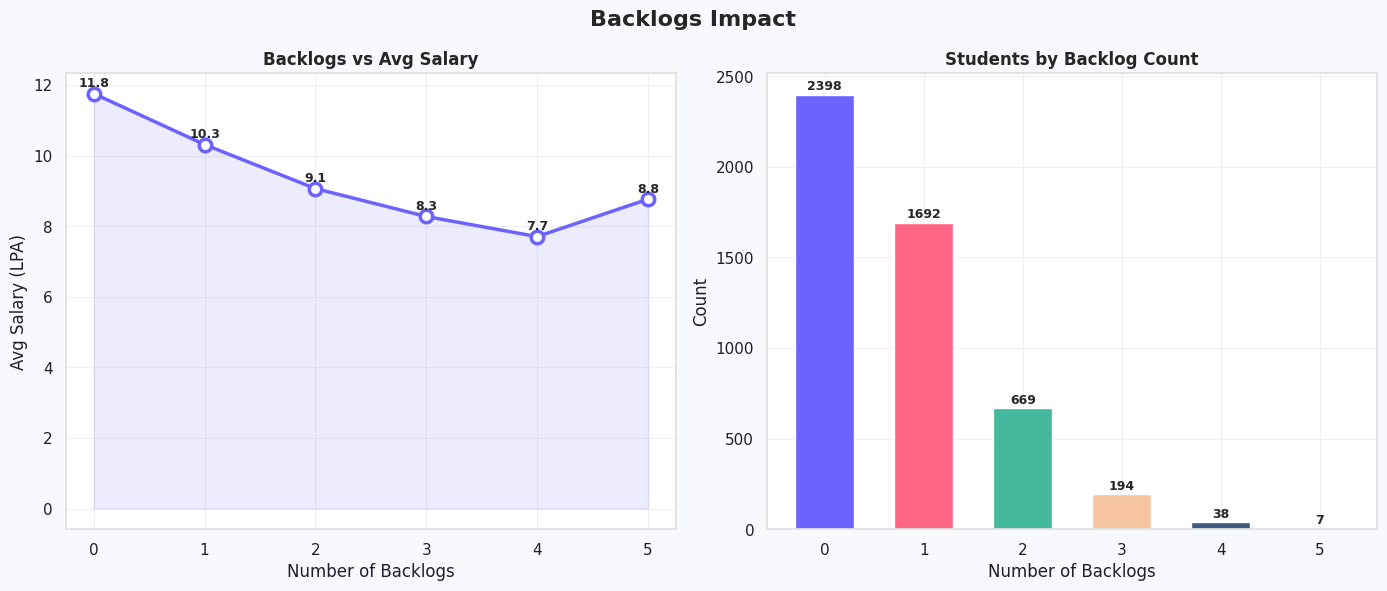


📌 Backlog–Salary correlation: -0.208
   Avg salary with 0 backlogs: 11.8 LPA
   Avg salary with 2 backlogs: 9.1 LPA
   → 2 backlogs costs approx 2.7 LPA on average.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Backlogs Impact", fontsize=16, fontweight="bold")

# Line: avg salary vs backlogs
ax = axes[0]
bl_sal = df[df.backlogs <= 5].groupby('backlogs')['salary_lpa'].mean()
ax.plot(bl_sal.index, bl_sal.values, color=PALETTE[0], marker='o', markersize=9,
        linewidth=2.5, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(bl_sal.index, bl_sal.values, alpha=0.12, color=PALETTE[0])
for x, y in zip(bl_sal.index, bl_sal.values):
    ax.text(x, y+0.2, f"{y:.1f}", ha='center', fontsize=9, fontweight='bold')
ax.set_title("Backlogs vs Avg Salary", fontweight="bold")
ax.set_xlabel("Number of Backlogs"); ax.set_ylabel("Avg Salary (LPA)")
ax.set_xticks(bl_sal.index)

# Bar: student count per backlog bucket
ax = axes[1]
bl_counts = df[df.backlogs <= 5]['backlogs'].value_counts().sort_index()
bars = ax.bar(bl_counts.index.astype(str), bl_counts.values,
              color=PALETTE[:len(bl_counts)], edgecolor='white', width=0.6)
for bar, v in zip(bars, bl_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+10, str(v),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title("Students by Backlog Count", fontweight="bold")
ax.set_xlabel("Number of Backlogs"); ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print("\n📌 Backlog–Salary correlation:", round(df['backlogs'].corr(df['salary_lpa']), 3))
sal_0 = df[df.backlogs == 0]['salary_lpa'].mean()
sal_2 = df[df.backlogs == 2]['salary_lpa'].mean()
print(f"   Avg salary with 0 backlogs: {sal_0:.1f} LPA")
print(f"   Avg salary with 2 backlogs: {sal_2:.1f} LPA")
print(f"   → 2 backlogs costs approx {sal_0 - sal_2:.1f} LPA on average.")


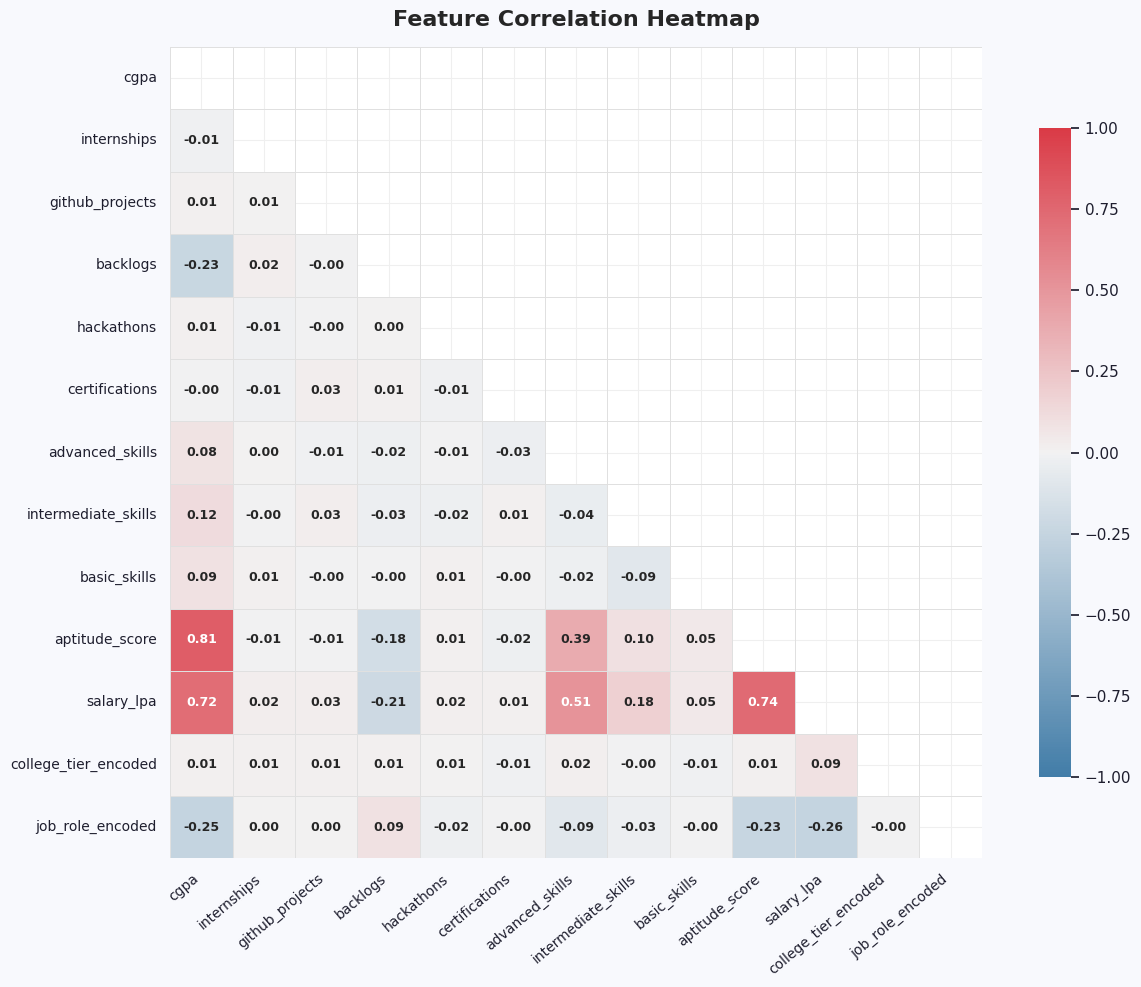


📌 Top correlations with salary_lpa:
   aptitude_score           : +0.736  ██████████████
   cgpa                     : +0.721  ██████████████
   advanced_skills          : +0.508  ██████████
   intermediate_skills      : +0.181  ███
   college_tier_encoded     : +0.093  █
   basic_skills             : +0.054  █
   github_projects          : +0.027  
   internships              : +0.025  
   hackathons               : +0.019  
   certifications           : +0.010  
   backlogs                 : -0.208  ████
   job_role_encoded         : -0.256  █████


In [23]:
# ── Correlation Heatmap ──────────────────────────────────────────
num_cols = [
    'cgpa', 'internships', 'github_projects', 'backlogs',
    'hackathons', 'certifications', 'advanced_skills',
    'intermediate_skills', 'basic_skills', 'aptitude_score',
    'salary_lpa', 'college_tier_encoded','job_role_encoded'
]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='#E0E0E0',
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=40, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print("\n📌 Top correlations with salary_lpa:")
salary_corr = corr['salary_lpa'].drop('salary_lpa').sort_values(ascending=False)
for feat, val in salary_corr.items():
    bar_str = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"   {feat:<25}: {sign}{abs(val):.3f}  {bar_str}")

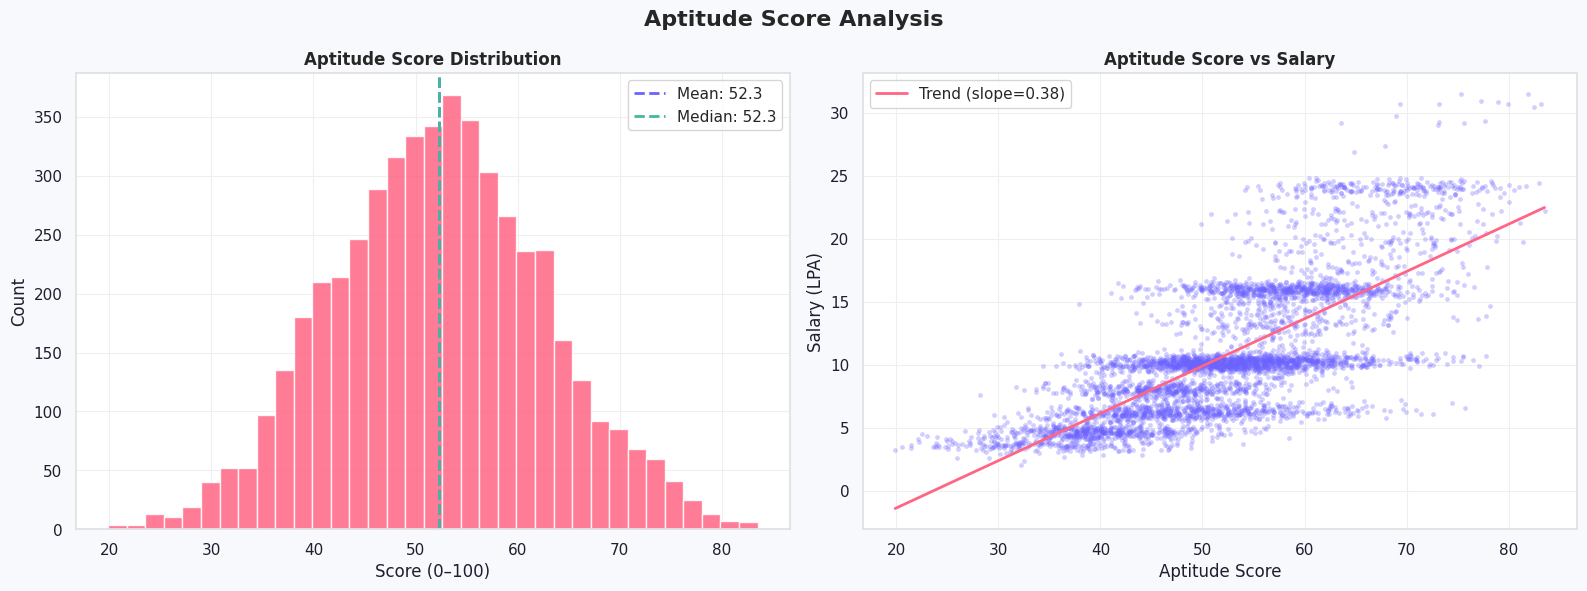


📌 Aptitude–Salary correlation: 0.736
   → Strong signal — include in model features.
   Range: 19.9 – 83.5
   Mean: 52.3 | Std: 10.4


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle("Aptitude Score Analysis", fontsize=16, fontweight="bold")

# Distribution
ax = axes[0]
ax.hist(df['aptitude_score'], bins=35, color=PALETTE[1], alpha=0.85, edgecolor='white')
ax.axvline(df['aptitude_score'].mean(),   color=PALETTE[0], lw=2, ls='--',
           label=f"Mean: {df['aptitude_score'].mean():.1f}")
ax.axvline(df['aptitude_score'].median(), color=PALETTE[2], lw=2, ls='--',
           label=f"Median: {df['aptitude_score'].median():.1f}")
ax.set_title("Aptitude Score Distribution", fontweight="bold")
ax.set_xlabel("Score (0–100)"); ax.set_ylabel("Count")
ax.legend()

# Scatter vs salary
ax = axes[1]
ax.scatter(df['aptitude_score'], df['salary_lpa'],
           color=PALETTE[0], alpha=0.3, s=12, linewidths=0)
m, b = np.polyfit(df['aptitude_score'], df['salary_lpa'], 1)
x_line = np.linspace(df['aptitude_score'].min(), df['aptitude_score'].max(), 100)
ax.plot(x_line, m*x_line + b, color="#FF6584", lw=2, label=f"Trend (slope={m:.2f})")
ax.set_title("Aptitude Score vs Salary", fontweight="bold")
ax.set_xlabel("Aptitude Score"); ax.set_ylabel("Salary (LPA)")
ax.legend()

plt.tight_layout()
plt.show()

apt_corr = round(df['aptitude_score'].corr(df['salary_lpa']), 3)
print(f"\n📌 Aptitude–Salary correlation: {apt_corr}")
print(f"   → {'Strong signal — include in model features.' if abs(apt_corr) > 0.5 else 'Moderate signal — still include.'}")
print(f"   Range: {df['aptitude_score'].min():.1f} – {df['aptitude_score'].max():.1f}")
print(f"   Mean: {df['aptitude_score'].mean():.1f} | Std: {df['aptitude_score'].std():.1f}")















In [19]:
print("=" * 62)
print("  EDA SUMMARY — DECISIONS FOR FEATURE ENGINEERING & TRAINING")
print("=" * 62)

corr = df[['cgpa','aptitude_score','advanced_skills','intermediate_skills',
           'backlogs','college_tier_encoded','salary_lpa']].corr()['salary_lpa'].drop('salary_lpa')

print("\n📌 FEATURE IMPORTANCE (by correlation with salary):")
print(f"   1. CGPA               → {corr['cgpa']:.3f}   Strongest feature")
print(f"   2. Aptitude Score     → {corr['aptitude_score']:.3f}   Very strong (in-app test)")
print(f"   3. Advanced Skills    → {corr['advanced_skills']:.3f}   High impact")
print(f"   4. Intermediate Skills→ {corr['intermediate_skills']:.3f}   Moderate")
print(f"   5. Backlogs          → {corr['backlogs']:.3f}  Penalty signal")
print(f"   6. College Tier       → {corr['college_tier_encoded']:.3f}   Weak (CGPA dominates)")

role_counts = df['job_role'].value_counts()
ratio = role_counts.max() / role_counts.min()
print(f"\n📌 CLASS IMBALANCE:")
print(f"   Imbalance ratio: {ratio:.1f}x  → Use class_weight='balanced' in classifier")

sal_skew = df['salary_lpa'].skew()
print(f"\n📌 SALARY SKEWNESS: {sal_skew:.3f}")
if sal_skew < 1.0:
    print("   → Low skew. Train on raw salary_lpa — no log transform needed.")
else:
    print("   → Moderate skew. Random Forest handles it. Linear models may need log(salary).")

print("\n📌 FEATURES TO KEEP FOR TRAINING:")
keep = ['college_tier_encoded','cgpa','internships','github_projects','backlogs',
        'hackathons','certifications','advanced_skills','intermediate_skills',
        'basic_skills','aptitude_score']
for f in keep:
    print(f"   ✓ {f}")

print("\n📌 FEATURES TO DROP:")
print("   ✗ skills (raw string — already encoded into skill count columns)")
print("   ✗ college_tier (raw string — encoded as college_tier_encoded)")
print("   ✗ job_role (raw string — encoded as job_role_encoded)")
print("   ✗ salary_log (reference only — train on salary_lpa directly)")

print("\n" + "=" * 62)
print("  EDA COMPLETE — Proceed to Step 4: Feature Engineering")
print("=" * 62)


  EDA SUMMARY — DECISIONS FOR FEATURE ENGINEERING & TRAINING

📌 FEATURE IMPORTANCE (by correlation with salary):
   1. CGPA               → 0.721   Strongest feature
   2. Aptitude Score     → 0.736   Very strong (in-app test)
   3. Advanced Skills    → 0.508   High impact
   4. Intermediate Skills→ 0.181   Moderate
   5. Backlogs          → -0.208  Penalty signal
   6. College Tier       → 0.093   Weak (CGPA dominates)

📌 CLASS IMBALANCE:
   Imbalance ratio: 5.4x  → Use class_weight='balanced' in classifier

📌 SALARY SKEWNESS: 0.944
   → Low skew. Train on raw salary_lpa — no log transform needed.

📌 FEATURES TO KEEP FOR TRAINING:
   ✓ college_tier_encoded
   ✓ cgpa
   ✓ internships
   ✓ github_projects
   ✓ backlogs
   ✓ hackathons
   ✓ certifications
   ✓ advanced_skills
   ✓ intermediate_skills
   ✓ basic_skills
   ✓ aptitude_score

📌 FEATURES TO DROP:
   ✗ skills (raw string — already encoded into skill count columns)
   ✗ college_tier (raw string — encoded as college_tier_encoded